# Clase 5 — Agente con Tools sobre datos biomedicos

## Parte 1-B: Agente con Tool-Use

---

### Diferencia con el enfoque RAG

| | RAG Vectorial | Tool-Use Agent (este notebook) |
|---|---|---|
| **Como accede a los datos** | Embeddings + cosine similarity | El LLM decide que tool llamar |
| **Quien elige que info usar** | El retriever (mecanico) | El LLM (razona sobre que necesita) |
| **Ventaja** | Rapido, no depende del LLM para buscar | Mas flexible, puede combinar tools |
| **Desventaja** | Limitado a similitud semantica | Mas lento, usa mas tokens |

### Que es un agente con tools?

Un agente con tools es un LLM que tiene acceso a **funciones** que puede decidir llamar.
El flujo es un loop:

```
1. El usuario hace una pregunta
2. El LLM analiza la pregunta y decide que tool(s) llamar
3. Se ejecuta la tool y se devuelve el resultado al LLM
4. El LLM puede llamar otra tool o generar la respuesta final
5. Repetir hasta que el LLM responda sin llamar tools
```

> El LLM no ejecuta codigo — solo genera un JSON con el nombre de la tool y los argumentos.
> Tu codigo ejecuta la tool y le devuelve el resultado.

## Setup

Ejecuta estas celdas para instalar las dependencias necesarias.

In [290]:
%pip install -q requests google-generativeai
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [291]:
import requests
import xml.etree.ElementTree as ET
import json
import re
import unicodedata
import numpy as np
import google.generativeai as genai
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Setup completo!")

Setup completo!


In [ ]:
# Configura tu API key de Gemini
# Podes obtener una gratis en: https://aistudio.google.com/apikey
GEMINI_API_KEY = "eliminado"

genai.configure(api_key=GEMINI_API_KEY)

In [293]:
XML_URL = "https://api.wisemapping.com/api/restful/maps/2030512/document/xml-pub"

---

## Las tools disponibles (ya implementadas)

Tu agente tiene acceso a 4 tools ya programadas. **No necesitas modificar este codigo.**
Leelo para entender que hace cada una — lo vas a necesitar para escribir las descripciones.

| Tool | Que hace | Parametros |
|---|---|---|
| `fetch_full_xml` | Descarga y retorna TODOS los datos del mind map como texto | Ninguno |
| `get_section` | Retorna datos de UNA seccion especifica | `section_name` (str) |
| `list_sections` | Lista las secciones disponibles | Ninguno |
| `calculate` | Evalua una expresion matematica | `expression` (str) |

In [294]:
# ══════════════════════════════════════════════════════════════════════
# TOOLS YA IMPLEMENTADAS — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

def _parse_mindmap(xml_text: str) -> dict:
    """Parsea el XML del mind map y retorna un dict {seccion: [textos]}."""
    root = ET.fromstring(xml_text)
    central = root.find('.//topic[@central="true"]')
    if central is None:
        central = root.find('.//topic')

    def get_text(node):
        t = node.get('text', '')
        if not t:
            te = node.find('text')
            if te is not None and te.text:
                t = te.text.strip()
        return t

    def get_note(node):
        ne = node.find('note')
        return ne.text.strip() if ne is not None and ne.text else ''

    def collect(node, depth=0):
        lines = []
        text = get_text(node)
        note = get_note(node)
        if text:
            indent = "  " * depth
            lines.append(f"{indent}- {text}")
            if note:
                lines.append(f"{indent}  (Nota: {note})")
        for child in node.findall('topic'):
            lines.extend(collect(child, depth + 1))
        return lines

    sections = {}
    central_text = get_text(central)
    for branch in central.findall('topic'):
        name = get_text(branch)
        if name:
            sections[name] = collect(branch)
    return central_text, sections


def fetch_full_xml(xml_url: str) -> str:
    """Descarga el XML del mind map y lo retorna como texto legible."""
    resp = requests.get(xml_url)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    output = f"=== {title} ===\n\n"
    for section_name, lines in sections.items():
        output += "\n".join(lines) + "\n\n"
    return output


def get_section(xml_url: str, section_name: str) -> str:
    """Retorna los datos de una seccion especifica del mind map."""
    resp = requests.get(xml_url)
    resp.raise_for_status()
    _, sections = _parse_mindmap(resp.text)
    section_name_lower = section_name.lower()
    for name, lines in sections.items():
        if section_name_lower in name.lower():
            return f"Seccion: {name}\n" + "\n".join(lines)
    available = ", ".join(sections.keys())
    return f"Seccion '{section_name}' no encontrada. Secciones disponibles: {available}"


def list_sections(xml_url: str) -> str:
    """Lista todas las secciones principales del mind map."""
    resp = requests.get(xml_url)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    result = f"Mind map: {title}\n\nSecciones disponibles:\n"
    for i, name in enumerate(sections.keys(), 1):
        result += f"  {i}. {name}\n"
    return result


def calculate(expression: str) -> str:
    """Evalua una expresion matematica y retorna el resultado."""
    cleaned = re.sub(r'[^0-9+\-*/().,%\s]', '', expression)
    cleaned = cleaned.replace('%', '/100').replace(',', '')
    try:
        result = eval(cleaned)
        return f"{expression} = {result}"
    except Exception as e:
        return f"Error al calcular '{expression}': {e}"


# Verificar que las tools funcionan
print("Tools cargadas correctamente.\n")
print("Ejemplo - list_sections:")
print(list_sections(XML_URL))
print("\nEjemplo - get_section('Riesgos'):")
print(get_section(XML_URL, "Riesgos"))
print("\nEjemplo - calculate('1200 * 85000'):")
print(calculate("1200 * 85000"))

Tools cargadas correctamente.

Ejemplo - list_sections:


Mind map: ACME Precision Oncology

(March 2026 Board Update)

Secciones disponibles:
  1. Research Específico
  2. Datos Biomédicos Clave
  3. Modelos Predictivos
  4. Costos del Proyecto
  5. Ensayos Clínicos
  6. Impacto y Mercado
  7. Riesgos
  8. Futuro


Ejemplo - get_section('Riesgos'):
Seccion: Riesgos
- Riesgos
  - Off-target mutations
  - Resistencia tumoral
  - Regulación FDA/EMA estricta
  - Acceso limitado por costo

Ejemplo - calculate('1200 * 85000'):
1200 * 85000 = 102000000


---

## Ejercicio 1: Escribir las descripciones de las tools

Las tools ya estan programadas, pero el LLM no sabe que hacen ni cuando usarlas.
Eso se lo decis vos a traves de las **descripciones**.

Cada tool tiene un campo `"description"` que el LLM lee para decidir si la llama o no.
Una buena descripcion debe responder:
- **Que hace** la tool
- **Cuando** deberia usarla el agente (y cuando NO)
- **Que datos** devuelve

> Pensa en las descripciones como un "prompt" para el LLM sobre cada tool.
> Si la descripcion es vaga, el agente va a elegir mal.

**Completa las 4 descripciones en la celda de abajo.**

In [295]:
# ── TODO: Completa las descripciones de cada tool ────────────────────
#
# Pista: mira los ejemplos de output de la celda anterior para entender
# que devuelve cada tool. Usa esa info para escribir descripciones claras.

TOOL_DECLARATIONS = [
    {
        "name": "fetch_full_xml",
        "description": (
            # TODO: Describir que hace, cuando usarla, que devuelve
            "Descarga y devuelve TODO el contenido del mind map como texto plano. "
            "Úsala como último recurso si 'get_section' no encontró lo que buscás."

        ),
        "parameters": {
            "type": "object",
            "properties": {},
            "required": [],
        },
    },
    {
        "name": "get_section",
        "description": (
            # TODO: Describir que hace, cuando usarla, que devuelve.
            # Pista: incluir los nombres de las secciones disponibles
            # ayuda al LLM a saber que valores pasar como argumento.
            "Retorna TODOS los datos de UNA sección del mind map. "
            "HERRAMIENTA PRINCIPAL: SIEMPRE llamala antes de responder. "
            "Secciones: "
            "'Research Específico' (terapia, CRISPR, mutación EGFR), "
            "'Datos Biomédicos Clave' (cohorte, tasa respuesta, supervivencia), "
            "'Modelos Predictivos' (algoritmo IA DeepGene-X, precisión, tiempo análisis), "
            "'Costos del Proyecto' (I+D total, coste paciente, desarrollo IA), "
            "'Ensayos Clínicos' (Fase I/II/III, número pacientes por fase), "
            "'Impacto y Mercado' (mercado USD, pacientes elegibles/año), "
            "'Riesgos' (off-target, resistencia, regulación), "
            "'Futuro' (tecnologías futuras, nanorobots, multi-gen)."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "section_name": {
                    "type": "string",
                    "description": "Nombre (o parte del nombre) de la seccion a buscar",
                }
            },
            "required": ["section_name"],
        },
    },
    {
        "name": "list_sections",
        "description": (
            # TODO: Describir que hace y cuando usarla
            "Lista los nombres de las secciones disponibles, SIN sus datos. "
            "Úsala solo para saber qué secciones existen. "
            "Después SIEMPRE llamá a 'get_section' para obtener los datos."
            
        ),
        "parameters": {
            "type": "object",
            "properties": {},
            "required": [],
        },
    },
    {
        "name": "calculate",
        "description": (
            # TODO: Describir que hace, cuando usarla, dar ejemplos de expresiones
            "Evalúa una expresión matemática (ej: '1200 * 85000'). "
            "Usala para cualquier cálculo numérico. Nunca calcules mentalmente."
            
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "expression": {
                    "type": "string",
                    "description": "Expresion matematica a evaluar",
                }
            },
            "required": ["expression"],
        },
    },
]

# Verificacion: no dejar descripciones vacias
for tool in TOOL_DECLARATIONS:
    if not tool["description"].strip():
        print(f"  FALTA descripcion para: {tool['name']}")
    else:
        print(f"  OK: {tool['name']} ({len(tool['description'])} chars)")

  OK: fetch_full_xml (138 chars)
  OK: get_section (615 chars)
  OK: list_sections (169 chars)
  OK: calculate (120 chars)


---

## Ejercicio 2: Escribir el system prompt del agente

El system prompt define el comportamiento general del agente: como debe responder,
que debe hacer y que NO debe hacer.

Pensalo como las "instrucciones de trabajo" que le das a un empleado nuevo.
Un buen system prompt para un agente con tools deberia incluir:
- **Rol**: que es el agente y sobre que dominio trabaja
- **Regla de oro**: SIEMPRE usar las tools para obtener datos, NUNCA inventar
- **Formato**: como debe responder (conciso, con datos exactos, etc.)

**Escribe tu system prompt en la celda de abajo.**

In [296]:
# ── TODO: Escribe el system prompt del agente ────────────────────────

SYSTEM_PROMPT = """
Eres un Asistente de Inteligencia Biomédica experto de la empresa ACME. 
Tu objetivo es responder preguntas sobre los proyectos de terapia génica, ensayos clínicos y finanzas de la empresa.

REGLAS CRÍTICAS:
1. NO INVENTES DATOS: Si no encuentras la información en las herramientas, indícalo. 
2. USO DE TOOLS: Siempre utiliza las herramientas para obtener datos precisos. No confíes en tu conocimiento previo sobre medicina general para datos específicos de ACME.
3. PRECISIÓN: Si se solicita un cálculo (como costos totales o porcentajes), utiliza siempre la tool 'calculate'.
4. FLUJO DE TRABAJO: Si no sabes dónde buscar, primero usa 'list_sections'. Luego usa 'get_section' para ver los detalles.
5. IDIOMA: Responde siempre en el idioma en que se te pregunte (predominantemente Español).
6. CONCISIÓN: Sé directo y profesional. Incluye los nombres de las tecnologías (ej. CRISPR, DeepGene-X) y cifras exactas.
"""

---

## Ejercicio 3: Configurar y probar el agente

La clase `ToolAgent` ya esta implementada — solo necesita tu system prompt y tus tool declarations.

**No modifiques la clase.** Solo ejecuta la celda para crearla, y luego proba el agente.

In [297]:
# ══════════════════════════════════════════════════════════════════════
# CLASE ToolAgent — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

class ToolAgent:
    """
    Agente que usa function calling de Gemini para responder preguntas.
    Recibe un system prompt y tool declarations configurados por el alumno.
    """

    # Mapeo nombre -> funcion Python (fijo, no se modifica)
    TOOL_FUNCTIONS = {
        "fetch_full_xml": lambda args: fetch_full_xml(XML_URL),
        "get_section":    lambda args: get_section(XML_URL, args["section_name"]),
        "list_sections":  lambda args: list_sections(XML_URL),
        "calculate":      lambda args: calculate(args["expression"]),
    }

    def __init__(self, system_prompt: str, tool_declarations: list[dict],
                 model_name: str = "gemini-2.5-flash-lite"):
        """
        Inicializa el agente.

        Args:
            system_prompt: instrucciones generales para el LLM
            tool_declarations: lista de tools con sus descripciones
            model_name: modelo de Gemini a usar (default: gemini-2.5-flash-lite)
        """
        self.model_name = model_name
        self.llm = genai.GenerativeModel(
            model_name=model_name,
            system_instruction=system_prompt,
            tools=[{"function_declarations": tool_declarations}],
        )
        self.tool_log = []
        print(f"ToolAgent inicializado con {len(tool_declarations)} tools (modelo: {model_name})")

    def _execute_tool(self, function_call) -> str:
        """Ejecuta una tool y retorna su resultado."""
        name = function_call.name
        args = dict(function_call.args) if function_call.args else {}
        func = self.TOOL_FUNCTIONS.get(name)
        if func is None:
            return f"Error: tool '{name}' no existe"
        result = func(args)
        self.tool_log[-1].append({"tool": name, "args": args})
        return result

    def answer(self, question: str, verbose: bool = False) -> str:
        """
        Responde una pregunta usando el loop de function calling.

        Args:
            question: pregunta del usuario
            verbose: si True, imprime cada tool call

        Returns:
            str: respuesta final del agente
        """
        self.tool_log.append([])
        chat = self.llm.start_chat()
        response = chat.send_message(question)

        max_iterations = 10
        for _ in range(max_iterations):
            function_calls = [
                part.function_call
                for part in response.candidates[0].content.parts
                if part.function_call and part.function_call.name
            ]

            if not function_calls:
                break

            tool_responses = []
            for fc in function_calls:
                if verbose:
                    args_str = dict(fc.args) if fc.args else {}
                    print(f"  >> Tool: {fc.name}({args_str})")
                result = self._execute_tool(fc)
                if verbose:
                    print(f"  << {result[:150]}{'...' if len(result) > 150 else ''}")
                tool_responses.append(
                    genai.protos.Part(
                        function_response=genai.protos.FunctionResponse(
                            name=fc.name, response={"result": result},
                        )
                    )
                )
            response = chat.send_message(genai.protos.Content(parts=tool_responses))

        text_parts = [
            part.text for part in response.candidates[0].content.parts
            if hasattr(part, 'text') and part.text
        ]
        return "\n".join(text_parts) if text_parts else "(Sin respuesta)"

In [298]:
# Crear el agente con TU system prompt y TUS tool declarations
agent = ToolAgent(
    system_prompt=SYSTEM_PROMPT,
    tool_declarations=TOOL_DECLARATIONS,
)

ToolAgent inicializado con 4 tools (modelo: gemini-2.5-flash-lite)


### Pruebas manuales

Usa `verbose=True` para ver que tools elige el agente. Proba con distintas preguntas
para verificar que tus descripciones y tu prompt funcionan bien **antes** de correr el benchmark.

In [299]:
# Proba tu agente con preguntas de ejemplo (modifica las preguntas libremente)
preguntas_test = [
    "Cual es la tasa de respuesta inicial del tratamiento?",
    "Que secciones de informacion hay disponibles?",
    "Cual es el costo total del trial si hay 1200 pacientes a $85,000 cada uno?",
    
]

for q in preguntas_test:
    print("=" * 60)
    print(f"Q: {q}")
    r = agent.answer(q, verbose=True)
    print(f"\nA: {r}\n")

Q: Cual es la tasa de respuesta inicial del tratamiento?
  >> Tool: get_section({'section_name': 'Datos Biomédicos Clave'})
  << Seccion: Datos Biomédicos Clave
- Datos Biomédicos Clave
  - Cohorte: 1,200 pacientes
  - Tasa de respuesta inicial: 68%
  - Reducción tumoral promedi...

A: La tasa de respuesta inicial del tratamiento es del 68%.

Q: Que secciones de informacion hay disponibles?
  >> Tool: list_sections({})
  << Mind map: ACME Precision Oncology

(March 2026 Board Update)

Secciones disponibles:
  1. Research Específico
  2. Datos Biomédicos Clave
  3. Modelos...

A: Las secciones disponibles son: 'Research Específico', 'Datos Biomédicos Clave', 'Modelos Predictivos', 'Costos del Proyecto', 'Ensayos Clínicos', 'Impacto y Mercado', 'Riesgos' y 'Futuro'.

Q: Cual es el costo total del trial si hay 1200 pacientes a $85,000 cada uno?
  >> Tool: calculate({'expression': '1200 * 85000'})
  << 1200 * 85000 = 102000000

A: (Sin respuesta)



---

## Ejercicio 4: Evaluar con el benchmark

Dos sistemas de evaluacion:
1. **Keywords**: mecanico — busca palabras clave exactas en la respuesta
2. **LLM-as-a-Judge**: un segundo LLM evalua la calidad de la respuesta

**No modifiques estas celdas** — solo ejecutalas.

In [300]:
# ══════════════════════════════════════════════════════════════════════
# BENCHMARK Y EVALUACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

BENCHMARK = [
    {
        "question": "Que tipo de terapia esta desarrollando ACME para cancer de pulmon?",
        "expected_keywords": ["terapia genica", "CRISPR-Cas9", "NSCLC"],
        "expected_answer": "Terapia genica dirigida usando edicion genetica basada en CRISPR-Cas9 para cancer de pulmon de celulas no pequenas (NSCLC)."
    },
    {
        "question": "Cual es la mutacion especifica que ACME esta intentando corregir?",
        "expected_keywords": ["EGFR-L858R"],
        "expected_answer": "La mutacion EGFR-L858R."
    },
    {
        "question": "Cuantos pacientes tiene la cohorte del ensayo clinico de ACME?",
        "expected_keywords": ["1200"],
        "expected_answer": "1,200 pacientes."
    },
    {
        "question": "Cual es la tasa de respuesta inicial del tratamiento?",
        "expected_keywords": ["68%"],
        "expected_answer": "68%."
    },
    {
        "question": "Como se llama el algoritmo propietario de inteligencia artificial de ACME?",
        "expected_keywords": ["DeepGene-X"],
        "expected_answer": "DeepGene-X."
    },
    {
        "question": "Cual es la precision del modelo predictivo de ACME y cuanto tarda en analizar un paciente?",
        "expected_keywords": ["89%", "3.2"],
        "expected_answer": "89% de precision, y tarda 3.2 minutos por paciente."
    },
    {
        "question": "Cuanto invirtio ACME en total en I+D y cuanto especificamente en desarrollo de IA?",
        "expected_keywords": ["420", "$60M"],
        "expected_answer": "I+D total: $420M USD. Desarrollo IA: $60M."
    },
    {
        "question": "Cuantos pacientes participaron en la Fase III del ensayo clinico?",
        "expected_keywords": ["820"],
        "expected_answer": "820 pacientes."
    },
    {
        "question": "Cual es el mercado objetivo en dolares y cuantos pacientes son elegibles por anio?",
        "expected_keywords": ["18", "2.1M"],
        "expected_answer": "Mercado objetivo de $18B USD con 2.1 millones de pacientes elegibles por anio."
    },
    {
        "question": "Cuales son las tecnologias futuras que ACME planea integrar?",
        "expected_keywords": ["nanorobots", "multi-gen"],
        "expected_answer": "Terapias multi-gen target e integracion con nanorobots."
    },
]


def normalize_text(text: str) -> str:
    """Normaliza texto: minusculas, remueve acentos y separadores de miles."""
    text = text.lower()
    text = text.replace(',', '').replace('.', ' ')  # separadores de miles
    nfkd = unicodedata.normalize('NFKD', text)
    return ''.join(c for c in nfkd if not unicodedata.combining(c))


def run_keyword_benchmark(agent, benchmark):
    results = []
    total_score = 0
    print("=" * 70)
    print("BENCHMARK 1: KEYWORDS")
    print("=" * 70)
    for i, item in enumerate(benchmark):
        question = item["question"]
        expected_kw = item["expected_keywords"]
        try:
            response = agent.answer(question)
        except Exception as e:
            response = f"ERROR: {e}"
        response_normalized = normalize_text(response)
        kw_found = [kw for kw in expected_kw if normalize_text(kw) in response_normalized]
        kw_score = len(kw_found) / len(expected_kw)
        total_score += kw_score
        status = "PASS" if kw_score == 1.0 else ("PARTIAL" if kw_score > 0 else "FAIL")
        print(f"\n--- Q{i+1}/{len(benchmark)} [{status}] ---")
        print(f"Q: {question}")
        print(f"A: {response[:200]}{'...' if len(response) > 200 else ''}")
        print(f"Keywords: {kw_found}/{expected_kw} ({kw_score:.0%})")
        if hasattr(agent, 'tool_log') and agent.tool_log:
            print(f"Tools: {[c['tool'] for c in agent.tool_log[-1]]}")
        results.append({"question": question, "response": response, "kw_score": kw_score, "status": status})
    avg = total_score / len(benchmark)
    passed = sum(1 for r in results if r["status"] == "PASS")
    partial = sum(1 for r in results if r["status"] == "PARTIAL")
    failed = sum(1 for r in results if r["status"] == "FAIL")
    print(f"\n{'='*70}\nKEYWORD SCORE: {avg:.0%}  |  PASS: {passed}  PARTIAL: {partial}  FAIL: {failed}\n{'='*70}")
    return {"score": avg, "results": results}


def run_llm_judge_benchmark(keyword_results, benchmark):
    judge = genai.GenerativeModel(
        model_name="gemini-2.5-flash-lite",
        system_instruction=(
            "Eres un evaluador estricto de respuestas. "
            "Evaluas si una respuesta del agente es correcta comparandola con la esperada. "
            "Responde SOLO con JSON valido, sin markdown, sin backticks:\n"
            '{"score": <0|1|2>, "reason": "<explicacion breve>"}\n'
            "0=INCORRECTA, 1=PARCIAL, 2=CORRECTA"
        ),
    )
    results = []
    total_score = 0
    print("=" * 70)
    print("BENCHMARK 2: LLM-AS-A-JUDGE")
    print("=" * 70)
    for i, item in enumerate(benchmark):
        question = item["question"]
        expected = item["expected_answer"]
        agent_response = keyword_results["results"][i]["response"]
        prompt = f"PREGUNTA: {question}\nRESPUESTA ESPERADA: {expected}\nRESPUESTA DEL AGENTE: {agent_response}\n\nEvalua. Responde SOLO con JSON."
        try:
            raw = judge.generate_content(prompt).text.strip()
            raw = raw.replace("```json", "").replace("```", "").strip()
            ev = json.loads(raw)
            score = ev.get("score", 0)
            reason = ev.get("reason", "Sin razon")
        except Exception as e:
            score = 0
            reason = f"Error del juez: {e}"
        total_score += score
        status = {2: "PASS", 1: "PARTIAL", 0: "FAIL"}.get(score, "ERROR")
        print(f"\n--- Q{i+1}/{len(benchmark)} [{status}] (score={score}/2) ---")
        print(f"Q: {question}")
        print(f"A: {agent_response[:200]}{'...' if len(agent_response) > 200 else ''}")
        print(f"Juez: {reason}")
        results.append({"question": question, "response": agent_response, "judge_score": score, "judge_reason": reason, "status": status})
    max_possible = len(benchmark) * 2
    avg_pct = (total_score / max_possible) * 100
    passed = sum(1 for r in results if r["status"] == "PASS")
    partial = sum(1 for r in results if r["status"] == "PARTIAL")
    failed = sum(1 for r in results if r["status"] == "FAIL")
    print(f"\n{'='*70}\nLLM JUDGE SCORE: {total_score}/{max_possible} ({avg_pct:.0f}%)  |  PASS: {passed}  PARTIAL: {partial}  FAIL: {failed}\n{'='*70}")
    return {"score": avg_pct / 100, "total": total_score, "max": max_possible, "results": results}


print(f"Benchmark cargado: {len(BENCHMARK)} preguntas")

Benchmark cargado: 10 preguntas


In [301]:
# Correr benchmark de keywords
agent.tool_log = []
keyword_results = run_keyword_benchmark(agent, BENCHMARK)

BENCHMARK 1: KEYWORDS

--- Q1/10 [PARTIAL] ---
Q: Que tipo de terapia esta desarrollando ACME para cancer de pulmon?
A: I am developing a gene therapy for non-small cell lung cancer (NSCLC). The therapy utilizes CRISPR-Cas9 gene editing technology to target the EGFR-L858R mutation in adult patients.
Keywords: ['CRISPR-Cas9', 'NSCLC']/['terapia genica', 'CRISPR-Cas9', 'NSCLC'] (67%)
Tools: ['get_section']

--- Q2/10 [PASS] ---
Q: Cual es la mutacion especifica que ACME esta intentando corregir?
A: Aún estamos investigando la mutación específica que ACME está intentando corregir. Según la información disponible, el proyecto se centra en la terapia génica dirigida al cáncer de pulmón (NSCLC) y ut...
Keywords: ['EGFR-L858R']/['EGFR-L858R'] (100%)
Tools: ['get_section']

--- Q3/10 [FAIL] ---
Q: Cuantos pacientes tiene la cohorte del ensayo clinico de ACME?
A: (Sin respuesta)
Keywords: []/['1200'] (0%)
Tools: ['get_section']

--- Q4/10 [PASS] ---
Q: Cual es la tasa de respuesta inicial del t

In [302]:
# Correr benchmark LLM-as-a-Judge (reutiliza las respuestas anteriores)
judge_results = run_llm_judge_benchmark(keyword_results, BENCHMARK)

BENCHMARK 2: LLM-AS-A-JUDGE

--- Q1/10 [PASS] (score=2/2) ---
Q: Que tipo de terapia esta desarrollando ACME para cancer de pulmon?
A: I am developing a gene therapy for non-small cell lung cancer (NSCLC). The therapy utilizes CRISPR-Cas9 gene editing technology to target the EGFR-L858R mutation in adult patients.
Juez: La respuesta del agente menciona el tipo de terapia (terapia génica), la tecnología utilizada (CRISPR-Cas9) y el tipo de cáncer (cáncer de pulmón de células no pequeñas). Aunque no menciona explícitamente "edición genética dirigida", se infiere del uso de CRISPR-Cas9 para "target the EGFR-L858R mutation".

--- Q2/10 [PASS] (score=2/2) ---
Q: Cual es la mutacion especifica que ACME esta intentando corregir?
A: Aún estamos investigando la mutación específica que ACME está intentando corregir. Según la información disponible, el proyecto se centra en la terapia génica dirigida al cáncer de pulmón (NSCLC) y ut...
Juez: La respuesta del agente identifica correctamente la mut

### Visualizacion de resultados

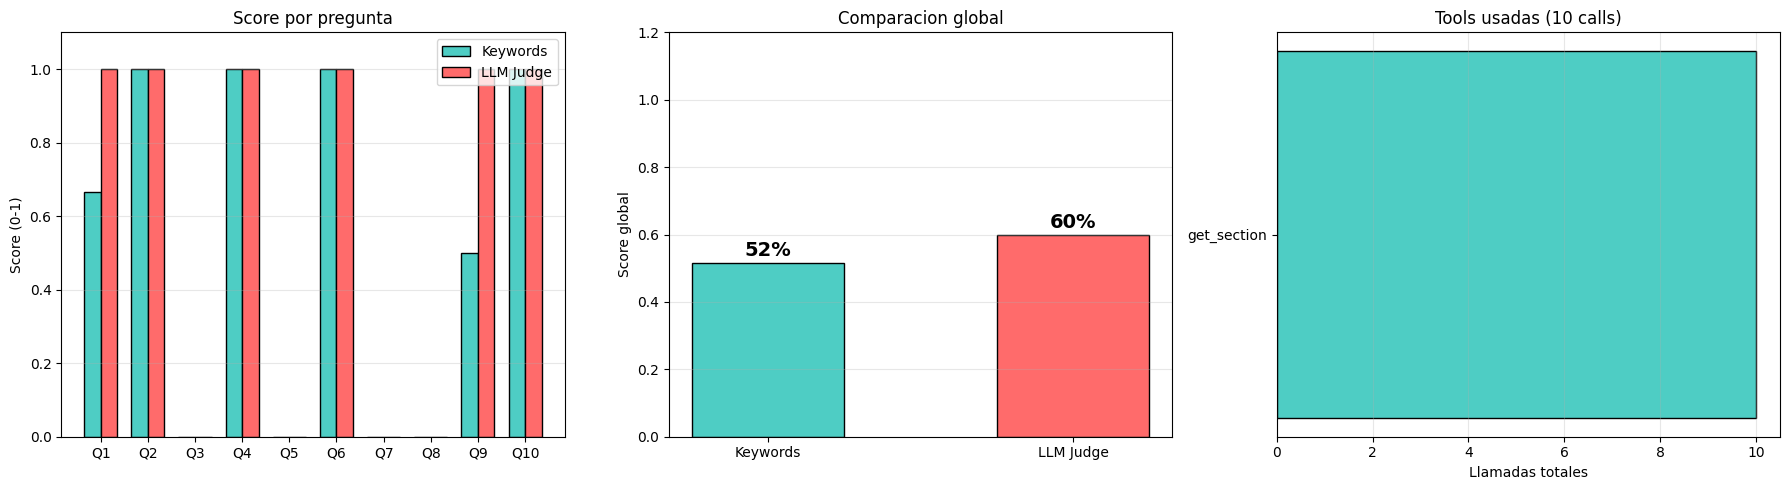


Discrepancias entre Keywords y LLM Judge:
------------------------------------------------------------
  Q1: Keywords=PARTIAL, Judge=PASS
        Juez: La respuesta del agente menciona el tipo de terapia (terapia génica), la tecnología utilizada (CRISPR-Cas9) y el tipo de cáncer (cáncer de pulmón de células no pequeñas). Aunque no menciona explícitamente "edición genética dirigida", se infiere del uso de CRISPR-Cas9 para "target the EGFR-L858R mutation".
  Q9: Keywords=PARTIAL, Judge=PASS
        Juez: La respuesta del agente es correcta y coincide exactamente con la información esperada, proporcionando el tamaño del mercado objetivo en dólares y la cantidad de pacientes elegibles por año.


In [303]:
# ══════════════════════════════════════════════════════════════════════
# VISUALIZACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
questions_short = [f"Q{i+1}" for i in range(len(BENCHMARK))]

# Panel 1: Scores por pregunta
kw_scores = [r["kw_score"] for r in keyword_results["results"]]
judge_scores = [r["judge_score"] / 2 for r in judge_results["results"]]
x = np.arange(len(questions_short))
width = 0.35
axes[0].bar(x - width/2, kw_scores, width, label="Keywords", color="#4ECDC4", edgecolor="black")
axes[0].bar(x + width/2, judge_scores, width, label="LLM Judge", color="#FF6B6B", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(questions_short)
axes[0].set_ylabel("Score (0-1)")
axes[0].set_title("Score por pregunta")
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Score global
methods = ["Keywords", "LLM Judge"]
scores = [keyword_results["score"], judge_results["score"]]
bars = axes[1].bar(methods, scores, color=["#4ECDC4", "#FF6B6B"], edgecolor="black", width=0.5)
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{score:.0%}", ha="center", fontweight="bold", fontsize=14)
axes[1].set_ylabel("Score global")
axes[1].set_title("Comparacion global")
axes[1].set_ylim(0, 1.2)
axes[1].grid(True, alpha=0.3, axis="y")

# Panel 3: Tools usadas
all_calls = [call["tool"] for log in agent.tool_log for call in log]
if all_calls:
    tool_counts = Counter(all_calls)
    tools_n = list(tool_counts.keys())
    tools_c = list(tool_counts.values())
    colors = ["#4ECDC4", "#FF6B6B", "#45B7D1", "#FFA07A"]
    axes[2].barh(tools_n, tools_c, color=colors[:len(tools_n)], edgecolor="black")
    axes[2].set_xlabel("Llamadas totales")
    axes[2].set_title(f"Tools usadas ({sum(tools_c)} calls)")
    axes[2].grid(True, alpha=0.3, axis="x")
else:
    axes[2].text(0.5, 0.5, "Sin tool calls", ha="center", va="center", fontsize=14)
    axes[2].set_title("Tools usadas")

plt.tight_layout()
plt.show()

# Discrepancias
print("\nDiscrepancias entre Keywords y LLM Judge:")
print("-" * 60)
has_disc = False
for i, (kr, jr) in enumerate(zip(keyword_results["results"], judge_results["results"])):
    if kr["status"] != jr["status"]:
        has_disc = True
        print(f"  Q{i+1}: Keywords={kr['status']}, Judge={jr['status']}")
        print(f"        Juez: {jr['judge_reason']}")
if not has_disc:
    print("  (Ninguna discrepancia)")

---

## Ejercicio 5: Analizar, refinar, re-evaluar

Mira los resultados del benchmark. Si hay preguntas con FAIL o PARTIAL:

1. **Diagnostica**: mira que tools uso el agente (o si no uso ninguna). El problema esta en las descripciones de las tools, en el system prompt, o en ambos?
2. **Refina**: volve a las celdas del Ejercicio 1 y/o 2 y modifica las descripciones o el prompt
3. **Re-evalua**: volve a correr las celdas del Ejercicio 3 y 4 para ver si mejoro

Podes repetir este ciclo cuantas veces quieras.

> Este loop de **evaluar → analizar → refinar → re-evaluar** es el flujo real
> de trabajo cuando se desarrollan agentes con LLMs.

---

## Ejercicio 5b: Comparar modelos — flash-lite vs flash

Hasta ahora usaste `gemini-2.5-flash-lite` (mas rapido y barato).
Ahora vas a correr **el mismo agente con el mismo prompt y tools** pero usando `gemini-2.5-flash`
(mas capaz pero mas lento/caro) y comparar los resultados.

> Esto te permite medir cuanto impacta la eleccion del modelo
> manteniendo todo lo demas igual (prompt, tools, benchmark).

In [304]:
# Crear agente con gemini-2.5-flash (el modelo mas capaz)
agent_flash = ToolAgent(
    system_prompt=SYSTEM_PROMPT,
    tool_declarations=TOOL_DECLARATIONS,
    model_name="gemini-2.5-flash",  # modelo mas capaz
)

# Correr el mismo benchmark
agent_flash.tool_log = []
print("\n>>> Corriendo benchmark con gemini-2.5-flash...\n")
keyword_results_flash = run_keyword_benchmark(agent_flash, BENCHMARK)

ToolAgent inicializado con 4 tools (modelo: gemini-2.5-flash)

>>> Corriendo benchmark con gemini-2.5-flash...

BENCHMARK 1: KEYWORDS

--- Q1/10 [PASS] ---
Q: Que tipo de terapia esta desarrollando ACME para cancer de pulmon?
A: ACME está desarrollando una terapia génica dirigida a cáncer de pulmón (NSCLC), utilizando edición genética basada en CRISPR-Cas9. El objetivo específico es la mutación EGFR-L858R.
Keywords: ['terapia genica', 'CRISPR-Cas9', 'NSCLC']/['terapia genica', 'CRISPR-Cas9', 'NSCLC'] (100%)
Tools: ['get_section']

--- Q2/10 [PASS] ---
Q: Cual es la mutacion especifica que ACME esta intentando corregir?
A: La mutación específica que ACME está intentando corregir es la mutación **EGFR-L858R**.
Keywords: ['EGFR-L858R']/['EGFR-L858R'] (100%)
Tools: ['get_section']

--- Q3/10 [PASS] ---
Q: Cuantos pacientes tiene la cohorte del ensayo clinico de ACME?
A: La cohorte del ensayo clínico de ACME tiene 1,200 pacientes.
Keywords: ['1200']/['1200'] (100%)
Tools: ['get_section']

-

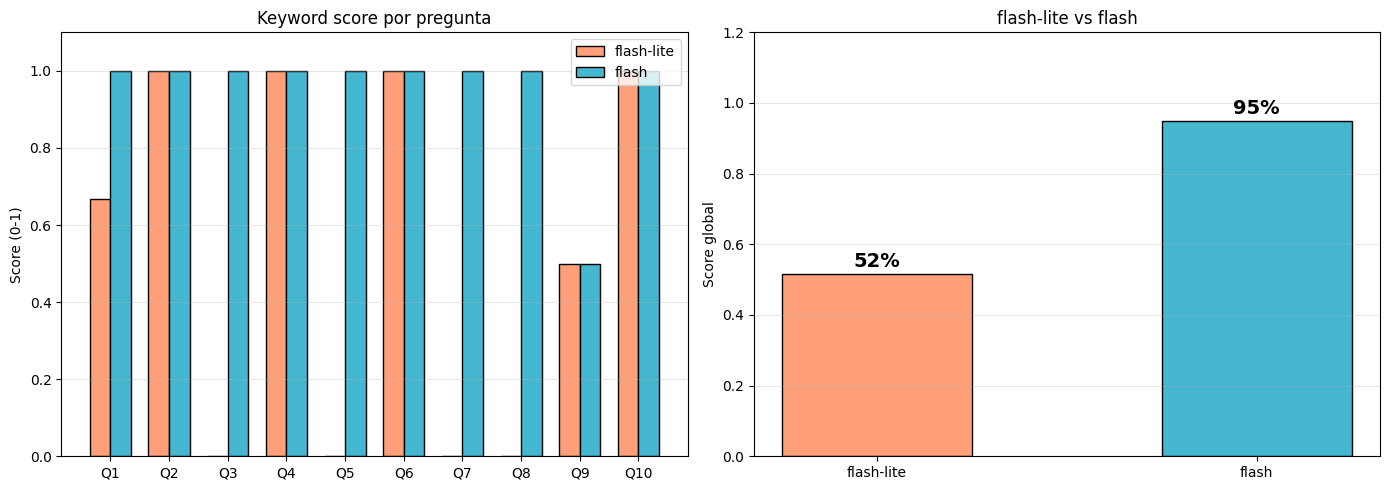


flash-lite: 52%
flash:      95%
flash mejora en 43%

Preguntas donde difieren:
  Q1: lite=PARTIAL, flash=PASS
  Q3: lite=FAIL, flash=PASS
  Q5: lite=FAIL, flash=PASS
  Q7: lite=FAIL, flash=PASS
  Q8: lite=FAIL, flash=PASS


In [305]:
# ── Comparacion visual: flash-lite vs flash ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

questions_short = [f"Q{i+1}" for i in range(len(BENCHMARK))]
x = np.arange(len(questions_short))
width = 0.35

# Panel 1: Score por pregunta
lite_scores = [r["kw_score"] for r in keyword_results["results"]]
flash_scores = [r["kw_score"] for r in keyword_results_flash["results"]]

axes[0].bar(x - width/2, lite_scores, width, label="flash-lite", color="#FFA07A", edgecolor="black")
axes[0].bar(x + width/2, flash_scores, width, label="flash", color="#45B7D1", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(questions_short)
axes[0].set_ylabel("Score (0-1)")
axes[0].set_title("Keyword score por pregunta")
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Score global
models = ["flash-lite", "flash"]
global_scores = [keyword_results["score"], keyword_results_flash["score"]]
bars = axes[1].bar(models, global_scores, color=["#FFA07A", "#45B7D1"], edgecolor="black", width=0.5)
for bar, score in zip(bars, global_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{score:.0%}", ha="center", fontweight="bold", fontsize=14)
axes[1].set_ylabel("Score global")
axes[1].set_title("flash-lite vs flash")
axes[1].set_ylim(0, 1.2)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Resumen
print(f"\nflash-lite: {keyword_results['score']:.0%}")
print(f"flash:      {keyword_results_flash['score']:.0%}")
diff = keyword_results_flash['score'] - keyword_results['score']
if diff > 0:
    print(f"flash mejora en {diff:.0%}")
elif diff < 0:
    print(f"flash-lite es mejor por {-diff:.0%}")
else:
    print("Mismo score")

# Detalle de diferencias
print("\nPreguntas donde difieren:")
for i in range(len(BENCHMARK)):
    ls = keyword_results["results"][i]["status"]
    fs = keyword_results_flash["results"][i]["status"]
    if ls != fs:
        print(f"  Q{i+1}: lite={ls}, flash={fs}")

---

## Ejercicio 6: Preguntas conceptuales

Responde en las celdas de abajo.

### 6.1 — System prompt
Que instrucciones incluiste en tu system prompt? Por que elegiste esas y no otras?
Si iteraste, que cambiaste entre versiones y que efecto tuvo?

Se añadieron instrucciones para prevenir alucinaciones, especialmente para que solo utilice datos provenientes de las herramientas. Además, se agregaron instrucciones para que mejore su precisión y dé una respuesta coherente al contexto del Prompt. Entre versiones se cambiaron las reglas del system prompt, ya sea reduciéndolas para no saturar al modelo o aumentándolas para que deje de dar "(Sin respuesta)" en las pruebas. También se modificaron las descripciones de las herramientas, donde la última versión de 'get_section' incluye además las secciones del archivo.

### 6.2 — Tool descriptions
Cual fue la descripcion mas dificil de escribir? Hubo alguna tool que el agente no usaba
hasta que mejoraste su descripcion? Que aprendiste sobre como el LLM interpreta las descripciones?

'get_section'. Especialmente esta porque el modelo o no la utilizaba o, si la utilizaba, no agregaba el parámetro correcto, ya sea porque alucinaba la respuesta o se rendía si el primer llamado de la herramienta no otorgaba la información requerida. Para mejorarlo, agregamos los nombres de las secciones en la misma descripción, lo que ahora permite al modelo poder usar 'get_section' con mayor facilidad. Se podría reforzar más este hands-on para casos futuros.

### 6.3 — Keywords vs LLM-as-a-Judge
Hubo discrepancias entre los dos metodos de evaluacion? Cual te parece mas justo y por que?
Que ventajas y desventajas tiene cada uno?

No hubieron discrepancias significativas, pero creemos que el LLM-as-a-Judge es más justo, debido a que el uso de Keywords limita mucho qué debe aparecer en la respuesta para considerarla correcta. Incluso, en casos donde se usen sinónimos o formas distintas de expresar una misma palabra, puede ocasionar que la prueba falle.

### 6.4 — RAG Tool-Use vs RAG vectorial
Cuando conviene usar cada enfoque? En que escenarios tool-use es claramente mejor?
Y en cuales RAG seria preferible?

Creemos que el enfoque de Tool-Use es mejor en escenarios donde los datos están estructurados (como el XML con el que se trabaja) y cuando se requiere que el modelo tome decisiones lógicas, como elegir qué sección leer primero o tener que aplicar cálculos. Por otro lado, el RAG vectorial sería preferible para lidiar con un volumen gigantesco de bases de datos desestructuradas (como buscar un concepto entre millones de PDFs), ya que en esos casos la búsqueda por similitud de embeddings es muchísimo más rápida y eficiente que forzar al agente a usar herramientas paso a paso.

### 6.5 — flash-lite vs flash
Que diferencias observaste entre los dos modelos? Hubo preguntas donde uno fallo y el otro no?
En que casos justificaria usar el modelo mas caro? Y en cuales el lite es suficiente?

Observamos una diferencia enorme en la forma de seguir protocolos. El modelo flash-lite falló en varias preguntas porque le cuesta más razonar y encadenar herramientas; a veces llamaba a una herramienta y se rendía sin completar el flujo. En cambio, el modelo flash pudo encadenar correctamente el flujo y obtener "PASS" en la gran mayoría. Justificaríamos usar el modelo más caro (flash) cuando el caso de uso requiere pasos de razonamiento complejos o cruzar mucha información. El modelo lite sería más que suficiente para un agente directo y sencillo que no requiera tomar tantas decisiones por su cuenta.